# Workbook 33 — combined DT-vein spacing and loading

This workbook converts DT vein radius and pitch into DT volume/mass fraction, neutron preheat, local N15 ignition time, and burned-DT:N15 bookkeeping. It tests the proposed scale lever directly: a larger target provides a longer inertial clock and a thicker mantle retains more DT-neutron energy, potentially allowing wider vein spacing and less DT.

The reference geometry is parallel cylindrical veins on a square lattice. It is a repeatable unit-cell screen, not a claim that this is the final three-dimensional network.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd()
while repo_root.name != 'CNO' and repo_root != repo_root.parent:
    repo_root = repo_root.parent
source_root = repo_root / 'analysis' / 'src'
if str(source_root) not in sys.path:
    sys.path.insert(0, str(source_root))

from cno_sweep import load_builtin_neutron_cross_sections
from cno_sweep.layered_driver import evolve_layered_pressure_pulse
from cno_sweep.n15_pusher import additive_volume_density
from cno_sweep.neutron_heating import fast_neutron_lengths
from cno_sweep.neutron_transport import Material, number_densities
from cno_sweep.vein_network import evaluate_vein_network_point


## Mechanical and neutron normalization

The mantle thickness and time-to-stagnation scaling come from the current cold Constantine-normalized pressure-driver trace. The 14.1-MeV energy attenuation length comes from Workbook 31's ENDF/B-VIII.0 screen. This does not reoptimize the implosion.

In [2]:
xs = load_builtin_neutron_cross_sections()
carbon_density_kg_m3 = 2267.0
helium_density_kg_m3 = 125.0
core_density_kg_m3 = 17.0 / (13.0 / carbon_density_kg_m3 + 4.0 / helium_density_kg_m3)
driver_density_kg_m3 = additive_volume_density(4.0)
normalization = evolve_layered_pressure_pulse(
    event_id='vein-spacing-normalization',
    initial_core_radius_m=1.0,
    initial_core_density_kg_m3=core_density_kg_m3,
    initial_abundances={'c13': 1.0, 'he4': 1.0},
    driver_n15_loaded_per_core_unit=1.0,
    driver_proton_ratio=4.0,
    n15_burn_fraction=1.0,
    dt_pairs_loaded_per_core_unit=0.0,
    dt_burn_fraction=0.0,
    dt_neutron_deposition_fraction=0.0,
    driver_density_kg_m3=driver_density_kg_m3,
    tamper_to_driver_mass_ratio=4.0,
    tamper_density_kg_m3=11340.0,
    burn_duration_over_characteristic_time=0.1,
)
trajan_material = Material(
    'p+N15 (4:1)',
    number_densities(driver_density_kg_m3, {'h1': 4.0, 'n15': 1.0}, xs),
)
neutron_length = fast_neutron_lengths(
    trajan_material, driver_density_kg_m3, xs,
).bounded_energy_attenuation_length_m
driver_thickness_per_R = normalization.initial_driver_thickness_m
peak_time_per_R = normalization.peak_time_s
pd.DataFrame([
    {'quantity': 'driver thickness/R0', 'value': driver_thickness_per_R, 'units': 'ratio'},
    {'quantity': 'time to stagnation/R0', 'value': peak_time_per_R, 'units': 's/m'},
    {'quantity': '14.1-MeV optimistic energy length', 'value': neutron_length, 'units': 'm at ordinary density'},
]).set_index('quantity')

,value,units
quantity,,
driver thickness/R0,4.405175e-01,ratio
time to stagnation/R0,4.429568e-07,s/m
14.1-MeV optimistic energy length,5.738072e-01,m at ordinary density


## Geometry and two ignition routes

For vein radius $a$ and pitch $s$, the DT volume fraction is $\phi_{DT}=\pi a^2/s^2$ and the furthest matrix point is $d_{max}=s/\sqrt{2}-a$ from a vein surface.

After the DT network reaches a segment, the furthest p+N15 can light by either:

1. **volumetric neutron induction:** retained DT-neutron energy preheats the mantle and that point burns locally; or
2. **charged-product bridge:** an N15 front advances from the vein through neutron-preheated fuel.

The faster route is selected. Charged-front speed remains the least certain term: it is a stated charged-product range divided by a zero-loss local induction time.

In [3]:
vein_radius_m = 0.10
scenarios = {
    'conservative timing': {
        'available_peak_fraction': 0.30,
        'dt_network_speed_m_s': 1.0e7,
        'charged_product_range_m': 0.0001099,
        'forward_n15_deposition_fraction': 0.25,
        'n15_source_burn_fraction': 0.50,
    },
    'likely screen': {
        'available_peak_fraction': 0.50,
        'dt_network_speed_m_s': 1.0e7,
        'charged_product_range_m': 0.010,
        'forward_n15_deposition_fraction': 0.25,
        'n15_source_burn_fraction': 0.50,
    },
}
display(pd.DataFrame(scenarios).T)
for name, values in scenarios.items():
    minimum_network_speed = driver_thickness_per_R / (
        values['available_peak_fraction'] * peak_time_per_R
    )
    print(f'{name}: DT network must exceed {minimum_network_speed/1e6:.3f} Mm/s before any N15 handoff time is available')

,available_peak_fraction,dt_network_speed_m_s,charged_product_range_m,forward_n15_deposition_fraction,n15_source_burn_fraction
conservative timing,0.3,10000000.0,0.00011,0.25,0.5
likely screen,0.5,10000000.0,0.01000,0.25,0.5


conservative timing: DT network must exceed 3.315 Mm/s before any N15 handoff time is available
likely screen: DT network must exceed 1.989 Mm/s before any N15 handoff time is available


The conservative charged range is the cold NIST-ASTAR alpha range divided by ordinary Trajan density. The 1-cm likely value is explicitly provisional; Workbook 20 must replace it with hot-plasma alpha and carbon stopping. Because the selected solutions below generally use volumetric neutron induction, that range does not control most listed points. A DT-network speed of only $3\times10^6$ m/s cannot traverse this complete mantle inside the conservative 30%-of-stagnation budget at any scale.

In [4]:
def widest_feasible_point(radius_m, scenario, n15_ledger_burn=0.50):
    available = scenario['available_peak_fraction'] * peak_time_per_R * radius_m
    thickness = driver_thickness_per_R * radius_m
    feasible = []
    for pitch_m in np.geomspace(2.01 * vein_radius_m, 3.0, 360):
        point = evaluate_vein_network_point(
            core_radius_m=radius_m,
            driver_thickness_m=thickness,
            vein_radius_m=vein_radius_m,
            vein_pitch_m=float(pitch_m),
            available_time_s=available,
            dt_network_path_m=thickness,
            dt_network_speed_m_s=scenario['dt_network_speed_m_s'],
            neutron_energy_attenuation_length_m=neutron_length,
            charged_product_range_m=scenario['charged_product_range_m'],
            forward_n15_deposition_fraction=scenario['forward_n15_deposition_fraction'],
            n15_source_burn_fraction=scenario['n15_source_burn_fraction'],
            n15_burn_fraction_for_ledger=n15_ledger_burn,
        )
        if point.feasible:
            feasible.append(point)
    return feasible[-1] if feasible else None

rows = []
points = {}
for radius_m in (10.0, 30.0, 100.0, 300.0, 1000.0, 3000.0, 10000.0):
    for scenario_name, scenario in scenarios.items():
        point = widest_feasible_point(radius_m, scenario)
        points[(radius_m, scenario_name)] = point
        if point is None:
            rows.append({'R0 (m)': radius_m, 'scenario': scenario_name, 'feasible': False})
            continue
        rows.append({
            'R0 (m)': radius_m,
            'scenario': scenario_name,
            'feasible': True,
            'driver thickness (m)': point.driver_thickness_m,
            'vein pitch (m)': point.vein_pitch_m,
            'furthest matrix distance (m)': point.maximum_matrix_distance_m,
            'DT volume fraction': point.dt_volume_fraction,
            'DT mass fraction': point.dt_mass_fraction,
            'neutron retention': point.neutron_retention_fraction,
            'neutron seed kT (keV)': point.neutron_seed_temperature_keV,
            'selected light-off': point.selected_local_lightoff_mode,
            'DT-network time (us)': point.dt_network_time_s * 1e6,
            'local light-off time (us)': point.selected_local_lightoff_time_s * 1e6,
            'available time (us)': point.available_time_s * 1e6,
            'burned DT pairs / burned N15 at f15=0.5': point.burned_dt_pairs_per_burned_n15,
        })
spacing_df = pd.DataFrame(rows)
spacing_df.set_index(['R0 (m)', 'scenario']).round(5)

feasible  driver thickness (m)  vein pitch (m)  \
R0 (m)  scenario                                                              
10.0    conservative timing      True               4.40517         1.02987   
        likely screen            True               4.40517         1.14436   
30.0    conservative timing      True              13.21552         1.20629   
        likely screen            True              13.21552         1.31046   
100.0   conservative timing      True              44.05175         1.38138   
        likely screen            True              44.05175         1.46714   
300.0   conservative timing      True             132.15524         1.52343   
        likely screen            True             132.15524         1.60588   
1000.0  conservative timing      True             440.51748         1.66749   
        likely screen            True             440.51748         1.74455   
3000.0  conservative timing      True            1321.55244         1.78440   
        likely screen            True            1321.55244         1.98277   
10000.0 conservative timing      True            4405.17480         1.92394   
        likely screen            True            4405.17480         2.61976   

                             furthest matrix distance (m)  DT volume fraction  \
R0 (m)  scenario                                                                
10.0    conservative timing                       0.62823             0.02962   
        likely screen                             0.70919             0.02399   
30.0    conservative timing                       0.75298             0.02159   
        likely screen                             0.82663             0.01829   
100.0   conservative timing                       0.87678             0.01646   
        likely screen                             0.93743             0.01460   
300.0   conservative timing                       0.97723             0.01354   
        likely screen                             1.03553             0.01218   
1000.0  conservative timing                       1.07909             0.01130   
        likely screen                             1.13358             0.01032   
3000.0  conservative timing                       1.16176             0.00987   
        likely screen                             1.30203             0.00799   
10000.0 conservative timing                       1.26043             0.00849   
        likely screen                             1.75245             0.00458   

                             DT mass fraction  neutron retention  \
R0 (m)  scenario                                                   
10.0    conservative timing           0.02926            0.99946   
        likely screen                 0.02370            0.99946   
30.0    conservative timing           0.02133            1.00000   
        likely screen                 0.01807            1.00000   
100.0   conservative timing           0.01626            1.00000   
        likely screen                 0.01442            1.00000   
300.0   conservative timing           0.01337            1.00000   
        likely screen                 0.01203            1.00000   
1000.0  conservative timing           0.01116            1.00000   
        likely screen                 0.01020            1.00000   
3000.0  conservative timing           0.00975            1.00000   
        likely screen                 0.00789            1.00000   
10000.0 conservative timing           0.00838            1.00000   
        likely screen                 0.00452            1.00000   

                             neutron seed kT (keV)  \
R0 (m)  scenario                                     
10.0    conservative timing               67.11886   
        likely screen                     54.04710   
30.0    conservative timing               48.54701   
        likely screen                     40.99797   
100.0   conservative timing               36.82761   


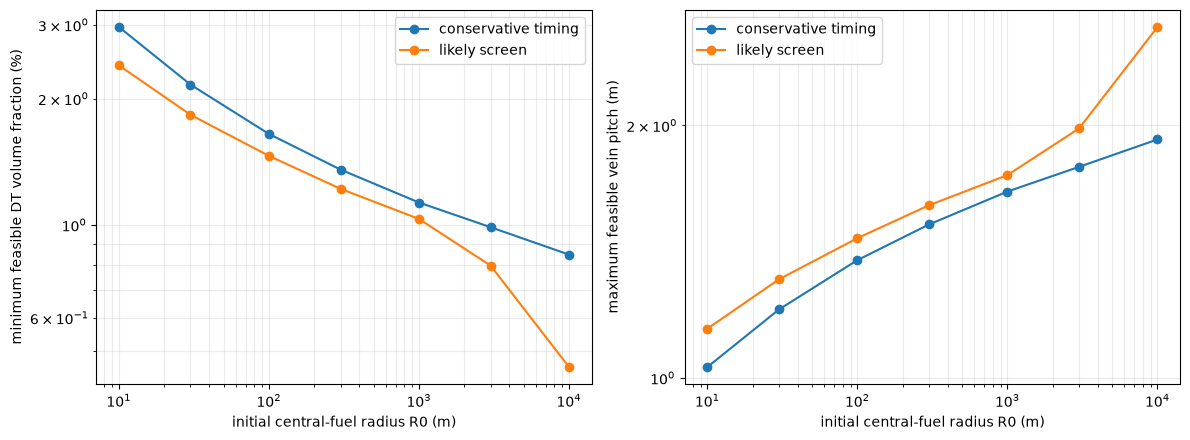

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for name, group in spacing_df[spacing_df.feasible].groupby('scenario'):
    axes[0].loglog(group['R0 (m)'], 100.0 * group['DT volume fraction'], marker='o', label=name)
    axes[1].loglog(group['R0 (m)'], group['vein pitch (m)'], marker='o', label=name)
axes[0].set_ylabel('minimum feasible DT volume fraction (%)')
axes[1].set_ylabel('maximum feasible vein pitch (m)')
for ax in axes:
    ax.set_xlabel('initial central-fuel radius R0 (m)')
    ax.grid(which='both', alpha=0.25)
    ax.legend()
plt.tight_layout()

## Ledger conversion

DT volume fraction is not yet the fuel-cycle number. The next table converts the selected 100-m and 1,000-m likely points into burned DT pairs per burned N15 for alternative achieved N15 burn fractions. It assumes complete DT burn; incomplete DT burn lowers deposited energy and therefore requires rerunning the spacing calculation, not merely rescaling the ledger afterward.

In [6]:
ledger_rows = []
for radius_m in (100.0, 1000.0):
    selected = points[(radius_m, 'likely screen')]
    for achieved_n15_burn in (0.25, 0.50, 0.75, 1.0):
        ledger_rows.append({
            'R0 (m)': radius_m,
            'DT volume fraction': selected.dt_volume_fraction,
            'achieved N15 burn fraction': achieved_n15_burn,
            'loaded DT pairs / loaded N15': selected.loaded_dt_pairs_per_loaded_n15,
            'burned DT pairs / burned N15': selected.loaded_dt_pairs_per_loaded_n15 / achieved_n15_burn,
        })
pd.DataFrame(ledger_rows).set_index(['R0 (m)', 'achieved N15 burn fraction']).style.format('{:.5g}')

## Review interpretation

* The current expected screen is approximately **1–2% DT by initial pusher volume and mass** over 10–1,000 m core radii, for 10-cm-radius veins and a $10^7$ m/s DT-network speed.
* Scale helps, but not without limit. At these points, retained neutrons preheat almost the entire p+N15 matrix enough for local induction before a charged N15 bridge wins. Increasing scale from 100 to 1,000 m therefore reduces the likely DT fraction only from about 1.45% to 1.04%.
* The DT-network transit is a hard separate gate. At the conservative time allowance, a network speed below about 3.32 Mm/s fails before N15 kinetics are considered.
* The fuel-cycle cost depends strongly on achieved N15 burn. A mantle that burns only half its loaded N15 roughly doubles burned-DT pairs per burned N15 compared with complete N15 burn.
* This is not yet a reference ratio. The next replacements are hot-plasma stopping, a connected three-dimensional vein topology, nonuniform neutron deposition, DT burn fraction/radius closure, and the pressure pulse produced by the calculated time history.